<a href="https://colab.research.google.com/github/VintaBytes/Ciencia-de-datos/blob/main/libros/ciencia-de-datos-con-python/volumen-05/cuadernos/CienciaDeDatos_Tomo5_Cuaderno01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Capítulo 1 · ¿Qué es Deep Learning?

En este cuaderno vamos a conectar el Machine Learning que ya conocemos con el nuevo recorrido por redes neuronales. Para hacerlo, compararemos un modelo clásico y una red neuronal pequeña sobre el mismo problema tabular.

El propósito no es estudiar todavía qué ocurre dentro de una red. En este primer contacto nos interesa observar qué permanece igual en el flujo de trabajo, qué cambia en el tipo de modelo y por qué una red neuronal no es automáticamente la mejor opción.


## Objetivos del cuaderno

Al finalizar este recorrido, deberías poder:

- reconocer a Deep Learning como una parte del Machine Learning;
- distinguir, a grandes rasgos, datos estructurados de datos no estructurados;
- comparar un modelo clásico y una red neuronal pequeña mediante una evaluación común;
- explicar por qué la elección del modelo depende del problema, los datos y los recursos disponibles.


## Importación de librerías

Usaremos herramientas que ya conocemos de `scikit-learn` para cargar datos, separar entrenamiento y prueba, preparar las variables y evaluar modelos. La única incorporación nueva será `MLPClassifier`, que nos permitirá utilizar una red neuronal pequeña sin detenernos todavía en su funcionamiento interno.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## 1. Datos estructurados y datos no estructurados

En un dataset tabular, cada fila suele representar una observación y cada columna una característica. Una vivienda puede describirse mediante superficie, cantidad de habitaciones y antigüedad; un vehículo, mediante potencia, peso y consumo.

Las imágenes, los textos y el audio también pueden convertirse en números, pero su estructura es más compleja. En una imagen importa la relación espacial entre píxeles; en un texto, el orden y el contexto de las palabras; en una señal de audio, los cambios a lo largo del tiempo.

| Tipo de datos | Ejemplos | Representación inicial habitual |
|---|---|---|
| Estructurados | viviendas, clientes, mediciones clínicas | filas y columnas con variables definidas |
| No estructurados | imágenes, texto, audio, video | grandes conjuntos de valores con relaciones espaciales o temporales |

Deep Learning resulta especialmente valioso cuando el modelo necesita aprender representaciones útiles a partir de información compleja. Sin embargo, para datos tabulares pequeños o medianos, los modelos clásicos siguen siendo alternativas muy competitivas.


## 2. Un problema tabular conocido

Trabajaremos con el dataset de diagnóstico de cáncer de mama incluido en `scikit-learn`. Contiene mediciones numéricas obtenidas de imágenes digitalizadas de muestras celulares. Esas mediciones ya fueron organizadas como variables tabulares, por lo que el modelo no recibirá las imágenes originales.

La tarea será clasificar cada caso como maligno o benigno. Usamos este dataset únicamente con fines educativos: el ejercicio no constituye un sistema de diagnóstico ni debe utilizarse para tomar decisiones médicas.


In [2]:
dataset = load_breast_cancer(as_frame=True)

X = dataset.data
y = dataset.target

datos_visibles = X[
    ["mean radius", "mean texture", "mean perimeter", "mean area"]
].copy()
datos_visibles["diagnóstico"] = y.map({0: "maligno", 1: "benigno"})

print(f"Filas: {X.shape[0]}")
print(f"Variables predictoras: {X.shape[1]}")
display(datos_visibles.head())


Filas: 569
Variables predictoras: 30


,mean radius,mean texture,mean perimeter,mean area,diagnóstico
0,17.99,10.38,122.80,1001.0,maligno
1,20.57,17.77,132.90,1326.0,maligno
2,19.69,21.25,130.00,1203.0,maligno
3,11.42,20.38,77.58,386.1,maligno
4,20.29,14.34,135.10,1297.0,maligno


La tabla muestra solo cuatro de las treinta variables predictoras para mantener una salida legible. El modelo utilizará todas las mediciones disponibles.

Este detalle es importante: aunque las variables provienen originalmente del análisis de imágenes, aquí ya recibimos características definidas y ordenadas en columnas. Por eso estamos frente a un problema tabular, no frente a un modelo que aprende directamente de los píxeles.


Antes de entrenar, observemos cuántos ejemplos hay de cada categoría. Esta revisión no reemplaza una exploración completa, pero permite conocer la composición básica de la variable objetivo.


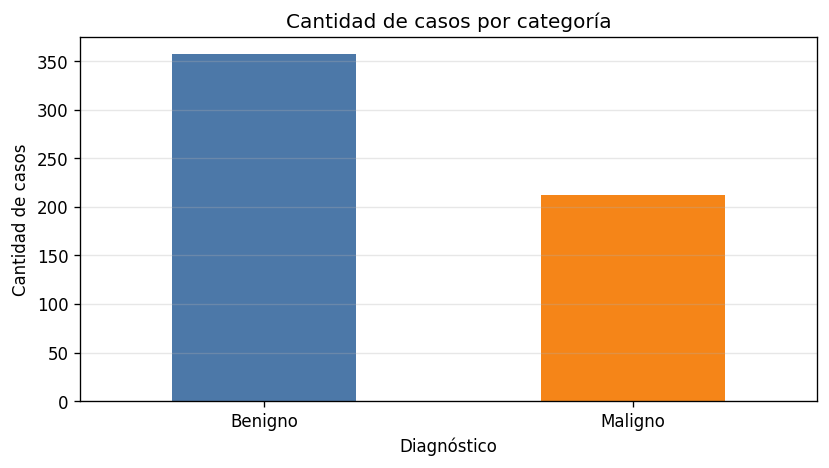

In [3]:
conteo_clases = y.map({0: "Maligno", 1: "Benigno"}).value_counts()

ax = conteo_clases.plot(
    kind="bar",
    color=["#4C78A8", "#F58518"],
    figsize=(7, 4),
)
ax.set_title("Cantidad de casos por categoría")
ax.set_xlabel("Diagnóstico")
ax.set_ylabel("Cantidad de casos")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


La categoría benigna es más frecuente que la maligna. La diferencia no impide realizar el ejercicio, pero recuerda que una métrica aislada debe interpretarse junto con la distribución de las clases y el contexto del problema.


## 3. Dos modelos dentro del mismo flujo de Machine Learning

Reservaremos el 25 % de los datos para la evaluación. Usamos `stratify=y` para conservar aproximadamente la proporción de categorías en ambos subconjuntos y una semilla fija para que la comparación sea reproducible.

También aplicaremos estandarización dentro de cada pipeline. Tanto la regresión logística como la red neuronal trabajan mejor en este ejemplo cuando las variables se encuentran en escalas comparables.


In [4]:
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print(f"Ejemplos para entrenamiento: {len(X_entrenamiento)}")
print(f"Ejemplos para prueba: {len(X_prueba)}")


Ejemplos para entrenamiento: 426
Ejemplos para prueba: 143


El primer pipeline utilizará regresión logística, un modelo clásico ya conocido. El segundo utilizará `MLPClassifier`, una red neuronal disponible en `scikit-learn`.

En esta etapa trataremos la configuración interna de la red como un detalle técnico. Más adelante estudiaremos de qué partes está formada y cómo aprende. Por ahora alcanza con saber que pertenece a la familia de los modelos neuronales y que puede entrenarse con el mismo esquema general: `fit()`, `predict()` y evaluación sobre datos no vistos.

Esta red pequeña funciona como puente conceptual. No representa las arquitecturas profundas que se utilizan para procesar imágenes, texto o audio a gran escala.


In [5]:
modelo_clasico = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42),
)

modelo_neuronal = make_pipeline(
    StandardScaler(),
    MLPClassifier(max_iter=1000, random_state=42),
)


Entrenamos ambos modelos exactamente con los mismos ejemplos. Después les pedimos que predigan las categorías del mismo conjunto de prueba. Así, la comparación se concentra en el modelo y no en una diferencia en los datos utilizados.


In [6]:
modelo_clasico.fit(X_entrenamiento, y_entrenamiento)
modelo_neuronal.fit(X_entrenamiento, y_entrenamiento)

prediccion_clasica = modelo_clasico.predict(X_prueba)
prediccion_neuronal = modelo_neuronal.predict(X_prueba)

print("Entrenamiento y predicciones completados.")


Entrenamiento y predicciones completados.


## 4. Comparar los resultados

Utilizaremos accuracy porque ya la conocemos y porque aquí buscamos una comparación introductoria. También contaremos los errores para traducir las proporciones a una cantidad concreta de casos del conjunto de prueba.

En un problema médico real, esta evaluación sería insuficiente: habría que analizar qué tipos de error comete cada modelo y considerar sus consecuencias.


In [7]:
resultados = pd.DataFrame(
    {
        "Modelo": ["Regresión logística", "Red neuronal pequeña"],
        "Accuracy": [
            accuracy_score(y_prueba, prediccion_clasica),
            accuracy_score(y_prueba, prediccion_neuronal),
        ],
        "Errores en prueba": [
            (prediccion_clasica != y_prueba).sum(),
            (prediccion_neuronal != y_prueba).sum(),
        ],
    }
)

resultados.assign(Accuracy=resultados["Accuracy"].round(3))


,Modelo,Accuracy,Errores en prueba
0,Regresión logística,0.986,2
1,Red neuronal pequeña,0.965,5


En esta ejecución, la regresión logística obtuvo una accuracy de aproximadamente **0,986** y cometió 2 errores. La red neuronal pequeña alcanzó aproximadamente **0,965** y cometió 5 errores.

Ambos resultados son altos dentro de este conjunto de prueba, pero no demuestran que los modelos sean perfectos ni que mantendrían el mismo desempeño con datos procedentes de otro contexto. Además, la diferencia observada corresponde a solo tres casos y a una partición particular del dataset.

Lo central para este capítulo es que la red neuronal no superó automáticamente al modelo clásico. En un dataset tabular pequeño, una alternativa más simple puede ofrecer un resultado igual o mejor.


Un gráfico con la escala completa de 0 a 1 permite comparar las accuracies sin exagerar visualmente una diferencia pequeña.


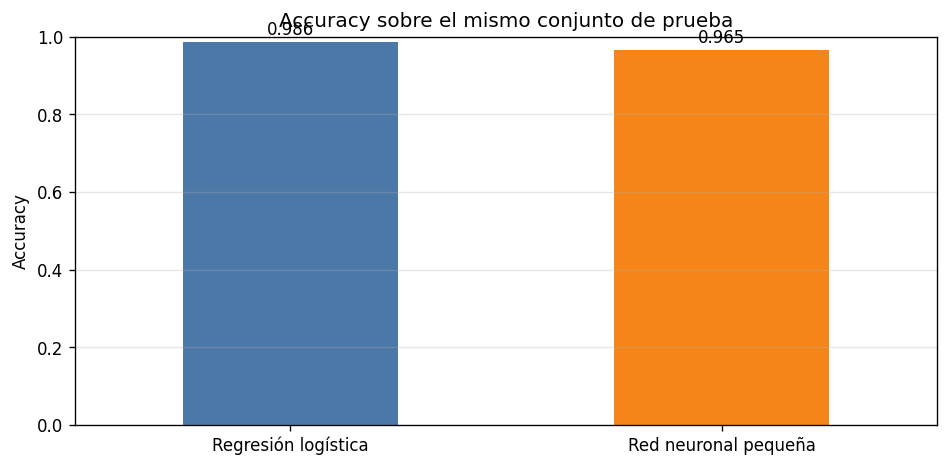

In [8]:
ax = resultados.plot(
    x="Modelo",
    y="Accuracy",
    kind="bar",
    legend=False,
    color=["#4C78A8", "#F58518"],
    figsize=(8, 4),
    ylim=(0, 1),
)
ax.set_title("Accuracy sobre el mismo conjunto de prueba")
ax.set_xlabel("")
ax.set_ylabel("Accuracy")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)

for barra, valor in zip(ax.patches, resultados["Accuracy"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.3f}",
        ha="center",
    )

plt.tight_layout()
plt.show()


La cercanía entre las barras refuerza una lectura prudente: ambos modelos resolvieron correctamente la mayoría de los casos de prueba y la diferencia entre ellos es reducida. Para sostener una comparación más general necesitaríamos repetir la evaluación de forma controlada, algo que ya aprendimos al trabajar con validación cruzada.


## 5. Mismos datos, decisiones diferentes

Dos modelos pueden alcanzar resultados parecidos y, aun así, equivocarse en observaciones distintas. Revisemos los casos en los que sus predicciones no coinciden.


In [9]:
comparacion = pd.DataFrame(
    {
        "valor_real": y_prueba.map({0: "maligno", 1: "benigno"}),
        "modelo_clasico": pd.Series(
            prediccion_clasica,
            index=y_prueba.index,
        ).map({0: "maligno", 1: "benigno"}),
        "red_neuronal": pd.Series(
            prediccion_neuronal,
            index=y_prueba.index,
        ).map({0: "maligno", 1: "benigno"}),
    }
)

desacuerdos = comparacion[
    comparacion["modelo_clasico"] != comparacion["red_neuronal"]
]

print(f"Cantidad de desacuerdos: {len(desacuerdos)}")
display(desacuerdos)


Cantidad de desacuerdos: 3


,valor_real,modelo_clasico,red_neuronal
291,benigno,benigno,maligno
363,benigno,benigno,maligno
526,benigno,benigno,maligno


Los modelos discreparon en 3 de los 143 casos de prueba. En esta partición, la regresión logística acertó esos tres casos y la red neuronal los clasificó como malignos.

Esta observación no permite afirmar que la regresión logística siempre será superior. Sí muestra que modelos diferentes construyen reglas de decisión diferentes y que una métrica global no cuenta toda la historia.


## 6. ¿Cuándo conviene considerar Deep Learning?

La comparación anterior no pretende decidir qué familia de modelos es mejor en general. Ayuda a construir un criterio inicial.

| Situación | Punto de partida razonable |
|---|---|
| Dataset tabular pequeño o mediano | Probar primero modelos clásicos y establecer una referencia |
| Pocas observaciones o recursos de cómputo limitados | Preferir inicialmente soluciones más simples |
| Necesidad fuerte de interpretación | Considerar modelos cuyo comportamiento resulte más fácil de examinar |
| Imágenes, texto, audio o secuencias con muchos ejemplos | Evaluar arquitecturas de Deep Learning adecuadas para ese tipo de dato |
| Características difíciles de diseñar manualmente | Considerar modelos capaces de aprender representaciones |

Deep Learning amplía las herramientas disponibles, pero no elimina la necesidad de comparar alternativas, evaluar con datos no vistos y justificar las decisiones tomadas.


## 7. Una modificación para explorar

Podés cambiar `random_state=42` por otro valor en la celda de separación, volver a ejecutar desde allí y observar si la diferencia entre modelos se mantiene.

Si los resultados cambian, no significa que el código esté mal. Significa que, con un conjunto de prueba relativamente pequeño, algunas observaciones pueden modificar la métrica. Esta exploración ayuda a recordar por qué no conviene sacar conclusiones generales a partir de una única partición.


## Cierre

En este cuaderno utilizamos una red neuronal pequeña sin estudiar todavía su mecanismo interno. Vimos que puede incorporarse al flujo de Machine Learning que ya conocemos: preparar los datos, separar entrenamiento y prueba, ajustar el modelo, predecir y evaluar.

También comprobamos una idea importante para el resto del tomo: una red neuronal no es automáticamente mejor por ser más compleja. En nuestro ejemplo tabular, la regresión logística obtuvo un resultado ligeramente superior. Deep Learning cobra especial relevancia cuando la tarea exige aprender representaciones complejas, como suele ocurrir con imágenes, texto, audio y secuencias, pero su conveniencia siempre depende del problema.

El próximo paso será abrir esa caja negra y estudiar la unidad de cálculo más sencilla sobre la que se construyen las redes neuronales.


## Para pensar

1. ¿Por qué este dataset se considera tabular aunque sus mediciones se hayan obtenido originalmente de imágenes?
2. ¿Qué conclusión sería incorrecto sacar a partir de la accuracy obtenida por la red neuronal?
3. ¿En qué tipo de problema esperarías que aprender representaciones resulte más importante que trabajar con columnas ya definidas?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
